# EDA định hướng Feature Engineering — Online Payments Fraud Detection

## Câu hỏi phân tích

1. Fraud tập trung ở loại giao dịch, mức tiền và thời điểm nào?
2. Số dư trước/sau của fraud khác non-fraud ra sao?
3. Ratio, balance discrepancy và binary flag có tín hiệu ổn định theo thời gian không?
4. Lịch sử destination có cho biết giao dịch hiện tại bất thường không?
5. Vì sao không đưa trực tiếp ID và một số trường gốc vào model?
6. Feature nào khả dụng trước giao dịch, feature nào chỉ có sau giao dịch?

In [25]:
%pip install matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 0. Thiết kế EDA

- Đọc cùng file raw như các notebook trước: <code>Synthetic_Financial_datasets_log.csv</code>.
- Sắp xếp theo <code>step</code>.
- Dùng 80% giá trị step đầu làm **development/discovery**, 20% cuối làm **holdout confirmation**; không cắt một giờ sang hai tập.
- Thống kê tính trên toàn bộ partition; biểu đồ phân phối dùng mẫu có seed.
- Ưu tiên fraud rate, lift, fraud capture và effect size, không chỉ số lượng/p-value.
- Luôn kiểm tra balance feature cả trong riêng <code>TRANSFER/CASH_OUT</code>.
- Luôn kiểm tra destination feature theo Customer/Merchant.
- Fit ngưỡng/bin trên development rồi áp nguyên trạng sang holdout để tránh look-ahead.

In [26]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (12, 5), "axes.titlesize": 13})
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

RANDOM_STATE = 42
EPSILON = 1e-5
PLOT_NON_FRAUD = 30_000
AUC_NON_FRAUD = 100_000
BLUE, RED, GREEN, GOLD = "#2F6BFF", "#E74C3C", "#2E8B57", "#F4B942"

## 1. Nạp dữ liệu và kiểm tra schema

Notebook đọc 10 trường trong mô tả bài toán. Balance dùng float64 để tái lập đúng phép so sánh/công thức feature engineering.

In [ ]:
DATA_PATH = Path("Synthetic_Financial_datasets_log.csv")
EXPECTED_COLUMNS = [
    "step", "type", "amount", "nameOrig", "oldbalanceOrg",
    "newbalanceOrig", "nameDest", "oldbalanceDest",
    "newbalanceDest", "isFraud",
]
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cannot find {DATA_PATH.resolve()}. Run 0_get_data.ipynb/get_data.py."
    )

header_columns = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
missing_columns = sorted(set(EXPECTED_COLUMNS) - set(header_columns))
extra_columns = sorted(set(header_columns) - set(EXPECTED_COLUMNS))
if missing_columns:
    raise ValueError(f"Thiếu cột bắt buộc: {missing_columns}")

dtype_map = {
    "step": "int32", "type": "category", "amount": "float64",
    "nameOrig": "string[pyarrow]", "oldbalanceOrg": "float64",
    "newbalanceOrig": "float64", "nameDest": "string[pyarrow]",
    "oldbalanceDest": "float64", "newbalanceDest": "float64", "isFraud": "int8",
}
try:
    df = pd.read_csv(DATA_PATH, usecols=EXPECTED_COLUMNS, dtype=dtype_map)
except (ImportError, TypeError):
    fallback = dtype_map | {"nameOrig": "string", "nameDest": "string"}
    df = pd.read_csv(DATA_PATH, usecols=EXPECTED_COLUMNS, dtype=fallback)

print(f"Shape: {len(df):,} rows x {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum()/1024**2:,.2f} MB")
print(f"Extra columns ignored: {extra_columns or 'None'}")
display(df.head())

Shape: 6,362,620 rows x 10 columns
Memory: 1,098.07 MB
Extra columns ignored: ['isFlaggedFraud']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,"9,839.640000",C1231006815,"170,136.000000","160,296.360000",M1979787155,0.000000,0.000000,0
1,1,PAYMENT,"1,864.280000",C1666544295,"21,249.000000","19,384.720000",M2044282225,0.000000,0.000000,0
2,1,TRANSFER,181.000000,C1305486145,181.000000,0.000000,C553264065,0.000000,0.000000,1
3,1,CASH_OUT,181.000000,C840083671,181.000000,0.000000,C38997010,"21,182.000000",0.000000,1
4,1,PAYMENT,"11,668.140000",C2048537720,"41,554.000000","29,885.860000",M1230701703,0.000000,0.000000,0


In [28]:
schema_report = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100),
    "n_unique": df.nunique(dropna=False),
})
display(schema_report)

quality_checks = pd.Series({
    "duplicate_rows": int(df.duplicated().sum()),
    "invalid_target": int((~df["isFraud"].isin([0, 1])).sum()),
    "negative_amount": int((df["amount"] < 0).sum()),
    "negative_oldbalanceOrg": int((df["oldbalanceOrg"] < 0).sum()),
    "negative_newbalanceOrig": int((df["newbalanceOrig"] < 0).sum()),
    "negative_oldbalanceDest": int((df["oldbalanceDest"] < 0).sum()),
    "negative_newbalanceDest": int((df["newbalanceDest"] < 0).sum()),
}, name="count")
display(quality_checks.to_frame())
print("Transaction types:", df["type"].astype(str).unique().tolist())
print("Target values:", sorted(df["isFraud"].unique().tolist()))

,dtype,missing,missing_pct,n_unique
step,int32,0,0.000000,743
type,category,0,0.000000,5
amount,float64,0,0.000000,5316900
nameOrig,string,0,0.000000,6353307
oldbalanceOrg,float64,0,0.000000,1845844
newbalanceOrig,float64,0,0.000000,2682586
nameDest,string,0,0.000000,2722362
oldbalanceDest,float64,0,0.000000,3614697
newbalanceDest,float64,0,0.000000,3555499
isFraud,int8,0,0.000000,2


,count
duplicate_rows,0
invalid_target,0
negative_amount,0
negative_oldbalanceOrg,0
negative_newbalanceOrig,0
negative_oldbalanceDest,0
negative_newbalanceDest,0


Transaction types: ['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN']
Target values: [0, 1]


## 2. Time-based discovery/holdout split

 Development dùng để khám phá và fit ngưỡng; holdout chỉ xác nhận độ ổn định. Pipeline hiện tại cắt theo vị trí row sau sort nên có thể chia cùng một step; notebook này chọn cutoff trên unique step. Tỷ lệ cắt là 80/20

In [29]:
df["_row_order"] = np.arange(len(df), dtype=np.int32)
df = df.sort_values(["step", "_row_order"], kind="stable").reset_index(drop=True)
unique_steps = np.sort(df["step"].unique())
if len(unique_steps) < 2:
    raise ValueError("Cần ít nhất 2 step để tách theo thời gian.")

cut_position = min(max(int(len(unique_steps) * 0.80), 1), len(unique_steps) - 1)
holdout_start_step = unique_steps[cut_position]
df["period"] = pd.Categorical(
    np.where(df["step"] < holdout_start_step, "development", "holdout"),
    categories=["development", "holdout"], ordered=True,
)
dev_mask = df["period"].eq("development")
holdout_mask = df["period"].eq("holdout")

split_summary = df.groupby("period", observed=True).agg(
    rows=("isFraud", "size"), min_step=("step", "min"), max_step=("step", "max"),
    fraud_count=("isFraud", "sum"), fraud_rate=("isFraud", "mean"),
)
split_summary["row_share"] = split_summary["rows"] / len(df)
display(split_summary)
print(f"Holdout starts at step={holdout_start_step}")

,rows,min_step,max_step,fraud_count,fraud_rate,row_share
period,,,,,,
development,6239040,1,594,6559,0.001051,0.980577
holdout,123580,595,743,1654,0.013384,0.019423


Holdout starts at step=595


## 3. Hàm hỗ trợ

- **Fraud rate:** xác suất fraud trong nhóm.
- **Lift:** fraud rate nhóm / fraud rate nền; lớn hơn 1 là rủi ro cao hơn trung bình.
- **Fraud capture:** phần trăm tổng fraud rơi vào nhóm.
- **Wilson interval:** khoảng tin cậy 95% cho fraud rate.
- **Direction-free AUC:** mức tách lớp đơn biến; gần 0.5 là yếu theo quan hệ đơn điệu nhưng feature vẫn có thể hữu ích qua threshold/tương tác.

In [30]:
def wilson_interval(successes, totals, z=1.96):
    successes, totals = np.asarray(successes, float), np.asarray(totals, float)
    safe_n = np.where(totals == 0, np.nan, totals)
    p = successes / safe_n
    den = 1 + z**2 / safe_n
    center = (p + z**2 / (2 * safe_n)) / den
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * safe_n)) / safe_n) / den
    return center - margin, center + margin

def fraud_profile(frame, by):
    out = frame.groupby(by, observed=True, dropna=False)["isFraud"].agg(
        total="size", fraud_count="sum"
    ).reset_index()
    base, total_fraud = frame["isFraud"].mean(), frame["isFraud"].sum()
    out["fraud_rate"] = out["fraud_count"] / out["total"]
    out["fraud_capture"] = out["fraud_count"] / total_fraud if total_fraud else np.nan
    out["lift_vs_base"] = out["fraud_rate"] / base if base else np.nan
    out["ci_low"], out["ci_high"] = wilson_interval(out["fraud_count"], out["total"])
    return out

def binary_signal_table(frame, features, period_name):
    base, total_fraud = frame["isFraud"].mean(), frame["isFraud"].sum()
    rows = []
    for feature in features:
        flag = frame[feature].eq(1)
        n1, n0 = int(flag.sum()), int((~flag).sum())
        f1 = int(frame.loc[flag, "isFraud"].sum())
        f0 = int(frame.loc[~flag, "isFraud"].sum())
        r1, r0 = (f1 / n1 if n1 else np.nan), (f0 / n0 if n0 else np.nan)
        low, high = wilson_interval([f1], [n1])
        rows.append({
            "period": period_name, "feature": feature, "support_when_1": n1 / len(frame),
            "fraud_rate_when_1": r1, "fraud_rate_when_0": r0,
            "risk_ratio_1_vs_0": r1 / r0 if r0 else np.inf,
            "lift_when_1": r1 / base if base else np.nan,
            "fraud_capture_when_1": f1 / total_fraud if total_fraud else np.nan,
            "ci_low_when_1": low[0], "ci_high_when_1": high[0],
        })
    return pd.DataFrame(rows)

def stratified_sample(frame, n_non_fraud=PLOT_NON_FRAUD):
    fraud = frame.loc[frame["isFraud"].eq(1)]
    normal = frame.loc[frame["isFraud"].eq(0)]
    if len(normal) > n_non_fraud:
        normal = normal.sample(n=n_non_fraud, random_state=RANDOM_STATE)
    return pd.concat([fraud, normal]).sample(frac=1, random_state=RANDOM_STATE)

def signed_log1p(values):
    values = np.asarray(values, float)
    return np.sign(values) * np.log1p(np.abs(values))

def robust_class_summary(frame, features):
    rows = []
    for feature in features:
        for label, group in frame.groupby("isFraud", observed=True):
            x = group[feature].replace([np.inf, -np.inf], np.nan).dropna().astype(float)
            rows.append({
                "feature": feature, "isFraud": int(label), "count": len(x),
                "q25": x.quantile(.25), "median": x.median(), "q75": x.quantile(.75),
                "p95": x.quantile(.95), "p99": x.quantile(.99),
            })
    return pd.DataFrame(rows)

def univariate_auc_table(frame, features, period_name):
    sample = stratified_sample(frame, AUC_NON_FRAUD)
    rows = []
    for feature in features:
        work = sample[[feature, "isFraud"]].replace([np.inf, -np.inf], np.nan).dropna()
        auc = np.nan
        if work[feature].nunique() >= 2 and work["isFraud"].nunique() == 2:
            auc = roc_auc_score(work["isFraud"], work[feature])
        rows.append({
            "period": period_name, "feature": feature, "auc_raw_direction": auc,
            "auc_direction_free": max(auc, 1-auc) if pd.notna(auc) else np.nan,
            "median_non_fraud": work.loc[work["isFraud"].eq(0), feature].median(),
            "median_fraud": work.loc[work["isFraud"].eq(1), feature].median(),
        })
    return pd.DataFrame(rows)

def cramers_v(frame, first, second):
    obs = pd.crosstab(frame[first], frame[second]).to_numpy(float)
    n = obs.sum()
    expected = np.outer(obs.sum(1), obs.sum(0)) / n
    chi2 = np.divide((obs-expected)**2, expected, out=np.zeros_like(expected), where=expected>0).sum()
    denominator = n * min(obs.shape[0]-1, obs.shape[1]-1)
    return np.sqrt(chi2/denominator) if denominator > 0 else np.nan

## 4. Target và mất cân bằng lớp

Fraud detection thường mất cân bằng mạnh. Accuracy có thể rất cao dù không phát hiện fraud nào. Vì vậy cần nhìn số lượng, fraud rate, tổng amount fraud và tỷ trọng giá trị fraud. Insight này quyết định metric: ưu tiên AUC-PR, recall, confusion matrix và cost-based threshold.

,transaction_count,total_amount,median_amount,transaction_share,amount_share
isFraud,,,,,
0,6354407,"1,132,336,529,331.929932","74,684.720000",0.998709,0.989465
1,8213,"12,056,415,427.840000","441,423.440000",0.001291,0.010535


Class ratio: 1 fraud / 773.7 non-fraud


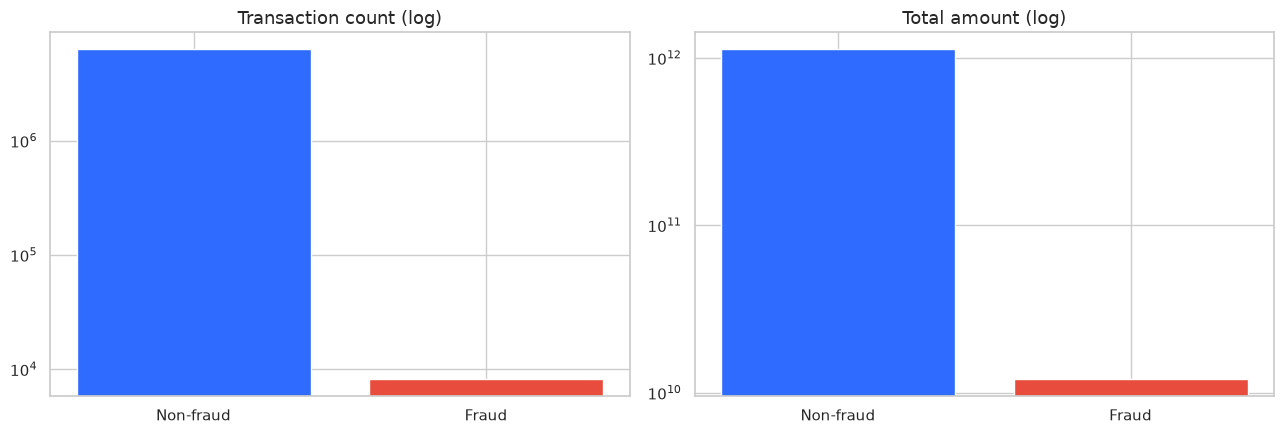

In [31]:
class_summary = df.groupby("isFraud").agg(
    transaction_count=("isFraud", "size"),
    total_amount=("amount", "sum"),
    median_amount=("amount", "median"),
)
class_summary["transaction_share"] = class_summary["transaction_count"] / len(df)
class_summary["amount_share"] = class_summary["total_amount"] / df["amount"].sum()
display(class_summary)
fraud_count = int(df["isFraud"].sum())
print(f"Class ratio: 1 fraud / {(len(df)-fraud_count)/max(fraud_count,1):,.1f} non-fraud")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(["Non-fraud", "Fraud"], class_summary["transaction_count"], color=[BLUE, RED])
axes[0].set_yscale("log"); axes[0].set_title("Transaction count (log)")
axes[1].bar(["Non-fraud", "Fraud"], class_summary["total_amount"], color=[BLUE, RED])
axes[1].set_yscale("log"); axes[1].set_title("Total amount (log)")
plt.tight_layout(); plt.show()

## 5. Type — cơ sở cho one-hot và nhóm giao dịch rủi ro

EDA kiểm tra type nào chứa fraud, fraud capture, lift và độ ổn định holdout. Nếu fraud tập trung ở TRANSFER/CASH_OUT, đó là cơ sở cho <code>type_TRANSFER</code>, <code>type_CASH_OUT</code>, <code>is_transfer_or_cashout</code>; <code>type_PAYMENT</code> là context/tín hiệu âm.

,type,total_dev,fraud_count_dev,fraud_rate_dev,fraud_capture_dev,lift_vs_base_dev,ci_low_dev,ci_high_dev,total_holdout,fraud_count_holdout,fraud_rate_holdout,fraud_capture_holdout,lift_vs_base_holdout,ci_low_holdout,ci_high_holdout
0,CASH_IN,1370906,0,0.000000,0.000000,0.000000,0.000000,0.000003,28378,0,0.000000,0.000000,0.000000,0.000000,0.000135
1,CASH_OUT,2198243,3289,0.001496,0.501448,1.423208,0.001446,0.001548,39257,827,0.021066,0.500000,1.573987,0.019692,0.022534
2,DEBIT,40443,0,0.000000,0.000000,0.000000,0.000000,0.000095,989,0,0.000000,0.000000,0.000000,0.000000,0.003869
3,PAYMENT,2108568,0,0.000000,0.000000,0.000000,-0.000000,0.000002,42927,0,0.000000,0.000000,0.000000,0.000000,0.000089
4,TRANSFER,520880,3270,0.006278,0.498552,5.971593,0.006067,0.006496,12029,827,0.068751,0.500000,5.136753,0.064365,0.073411


Cramér's V(type, target), development = 0.0532


,period,feature,support_when_1,fraud_rate_when_1,fraud_rate_when_0,risk_ratio_1_vs_0,lift_when_1,fraud_capture_when_1,ci_low_when_1,ci_high_when_1
0,development,is_transfer_or_cashout,0.435824,0.002412,0.000000,inf,2.294505,1.000000,0.002355,0.002471
0,holdout,is_transfer_or_cashout,0.415002,0.032251,0.000000,inf,2.409624,1.000000,0.030756,0.033815


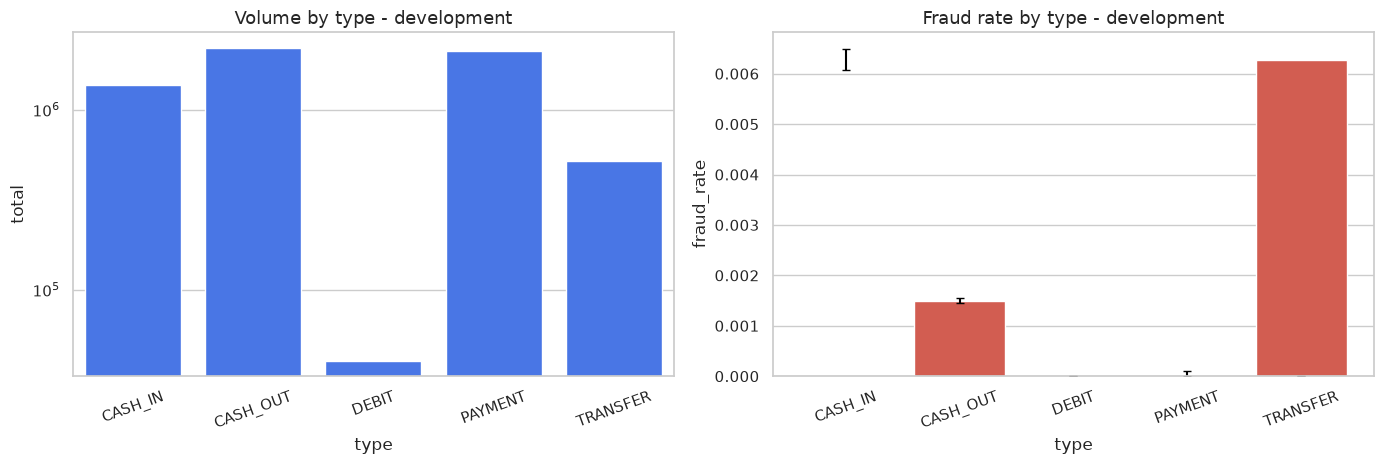

In [32]:
transaction_types = ["CASH_IN", "CASH_OUT", "DEBIT", "PAYMENT", "TRANSFER"]
for tx_type in transaction_types:
    df[f"type_{tx_type}"] = df["type"].eq(tx_type).astype("int8")
df["is_transfer_or_cashout"] = df["type"].isin(["TRANSFER", "CASH_OUT"]).astype("int8")
df["dest_channel"] = pd.Categorical(
    np.where(df["nameDest"].str.startswith("M", na=False), "Merchant", "Customer")
)

type_dev = fraud_profile(df.loc[dev_mask, ["type", "isFraud"]], "type")
type_hold = fraud_profile(df.loc[holdout_mask, ["type", "isFraud"]], "type")
display(type_dev.merge(type_hold, on="type", suffixes=("_dev", "_holdout")))
type_target_v = cramers_v(
    df.loc[dev_mask, ["type", "isFraud"]],
    "type",
    "isFraud",
)
print(f"Cramér's V(type, target), development = {type_target_v:.4f}")
display(pd.concat([
    binary_signal_table(df.loc[dev_mask, ["is_transfer_or_cashout", "isFraud"]], ["is_transfer_or_cashout"], "development"),
    binary_signal_table(df.loc[holdout_mask, ["is_transfer_or_cashout", "isFraud"]], ["is_transfer_or_cashout"], "holdout"),
]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ordered = type_dev.sort_values("total", ascending=False)
sns.barplot(data=ordered, x="type", y="total", color=BLUE, ax=axes[0])
axes[0].set_yscale("log"); axes[0].set_title("Volume by type - development")
risk_order = type_dev.sort_values("fraud_rate", ascending=False)
sns.barplot(data=risk_order, x="type", y="fraud_rate", color=RED, ax=axes[1])
axes[1].errorbar(np.arange(len(risk_order)), risk_order["fraud_rate"],
    yerr=[risk_order["fraud_rate"]-risk_order["ci_low"], risk_order["ci_high"]-risk_order["fraud_rate"]],
    fmt="none", ecolor="black", capsize=3)
axes[1].set_title("Fraud rate by type - development")
for ax in axes: ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

## 6. Amount và <code>is_large_amount</code>

Amount lệch phải nên biểu đồ dùng log1p. Ngưỡng large = Q3 + 1.5×IQR được fit **chỉ trên development**, sau đó áp dụng holdout. Cơ sở giữ feature là nhóm trên ngưỡng có lift/capture đáng kể và ổn định.

isFraud,non_fraud,fraud
0.000000,0.010000,0.000000
0.250000,"13,416.630000","127,916.670000"
0.500000,"74,842.590000","445,257.430000"
0.750000,"208,616.920000","1,503,166.155000"
0.900000,"364,848.850000","4,258,388.552000"
0.950000,"516,589.950000","7,487,070.754000"
0.990000,"1,593,492.446000","10,000,000.000000"
1.000000,"92,445,516.640000","10,000,000.000000"


Train-fitted threshold = 502,113.77


,period,feature,support_when_1,fraud_rate_when_1,fraud_rate_when_0,risk_ratio_1_vs_0,lift_when_1,fraud_capture_when_1,ci_low_when_1,ci_high_when_1
0,development,is_large_amount,0.053136,0.009324,0.000587,15.882373,8.868893,0.471261,0.009002,0.009657
0,holdout,is_large_amount,0.049118,0.125700,0.007582,16.578032,9.391793,0.461306,0.117596,0.134278


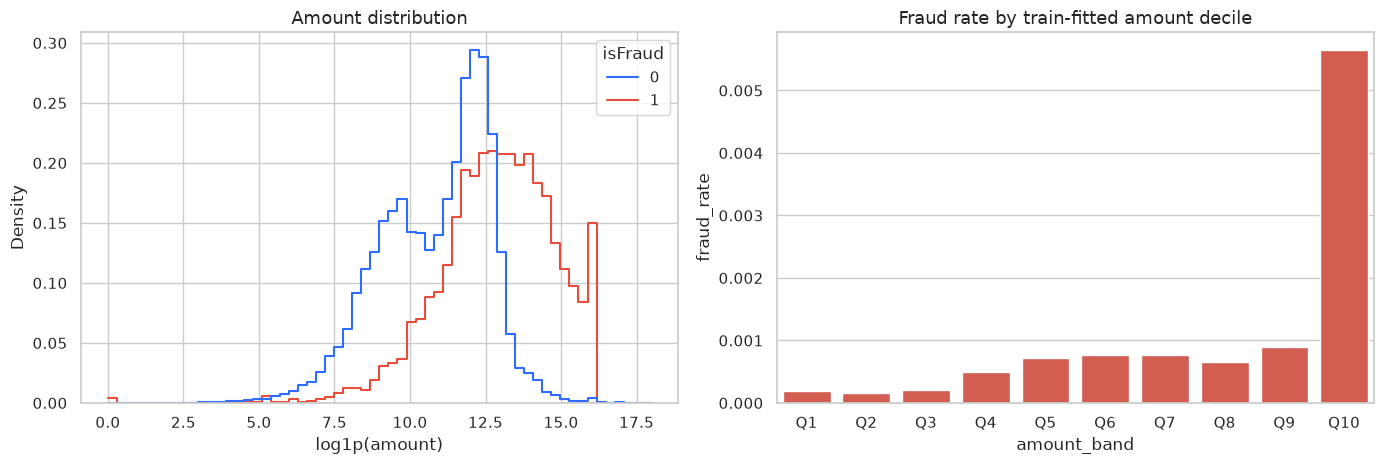

In [33]:
amount_quantiles = df.loc[dev_mask, ["amount", "isFraud"]].groupby("isFraud")["amount"].quantile(
    [0, .25, .5, .75, .9, .95, .99, 1]
).unstack(0).rename(columns={0: "non_fraud", 1: "fraud"})
display(amount_quantiles)

dev_amount = df.loc[dev_mask, "amount"]
q1, q3 = dev_amount.quantile(.25), dev_amount.quantile(.75)
iqr = q3 - q1
large_amount_threshold = q3 + 1.5 * iqr
df["is_large_amount"] = (df["amount"] > large_amount_threshold).astype("int8")
print(f"Train-fitted threshold = {large_amount_threshold:,.2f}")
display(pd.concat([
    binary_signal_table(df.loc[dev_mask, ["is_large_amount", "isFraud"]], ["is_large_amount"], "development"),
    binary_signal_table(df.loc[holdout_mask, ["is_large_amount", "isFraud"]], ["is_large_amount"], "holdout"),
]))

edges = np.unique(dev_amount.quantile(np.linspace(0, 1, 11)).to_numpy())
edges[0], edges[-1] = -np.inf, np.inf
bands = pd.DataFrame({
    "amount_band": pd.cut(dev_amount, edges, labels=[f"Q{i}" for i in range(1, len(edges))], include_lowest=True),
    "isFraud": df.loc[dev_mask, "isFraud"].to_numpy(),
})
amount_band_profile = fraud_profile(bands, "amount_band")
plot_amount = stratified_sample(df.loc[dev_mask, ["amount", "isFraud"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.histplot(data=plot_amount, x=np.log1p(plot_amount["amount"]), hue="isFraud",
    bins=60, stat="density", common_norm=False, element="step", fill=False,
    palette={0: BLUE, 1: RED}, ax=axes[0])
axes[0].set_xlabel("log1p(amount)"); axes[0].set_title("Amount distribution")
sns.barplot(data=amount_band_profile, x="amount_band", y="fraud_rate", color=RED, ax=axes[1])
axes[1].set_title("Fraud rate by train-fitted amount decile")
plt.tight_layout(); plt.show()

## 7. Time — từ step đến hour_of_day

<code>step</code> là giờ kể từ đầu mô phỏng, không phải ngày lịch. Dùng trực tiếp có thể học trend riêng của simulator. <code>hour_of_day = step % 24</code> giữ pattern trong ngày. Ta so sánh development/holdout và riêng TRANSFER/CASH_OUT. Với mô hình tuyến tính nên thử sin/cos vì 23 và 0 là hai giờ kề nhau; cây có thể dùng số nguyên trực tiếp.

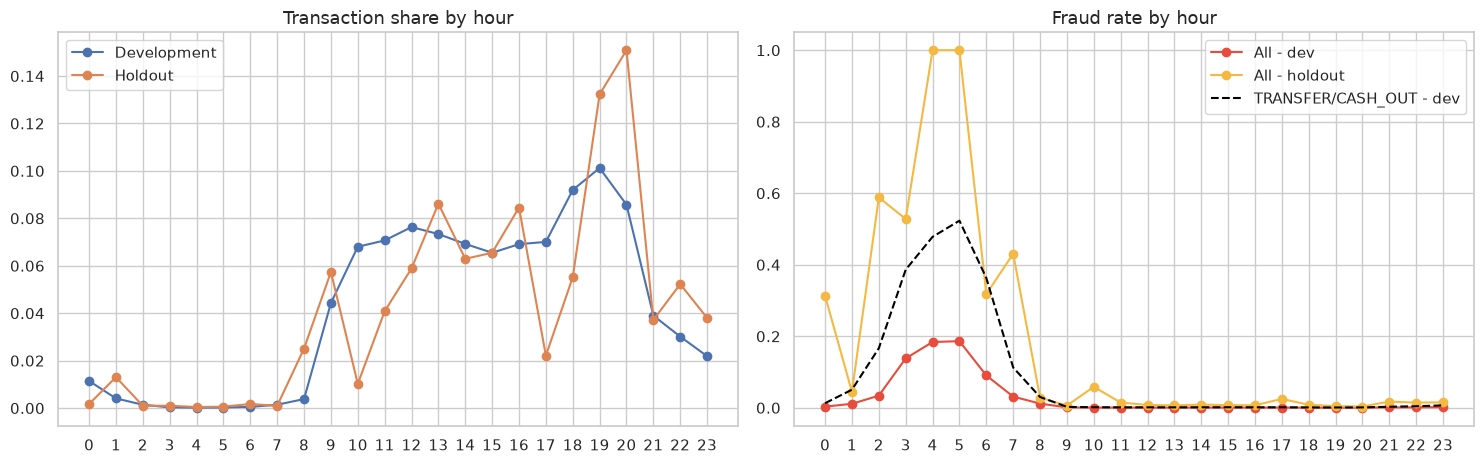

,hour_of_day,total,fraud_count,fraud_rate,fraud_capture,lift_vs_base,ci_low,ci_high,tx_share
0,0,71376,234,0.003278,0.035676,3.118486,0.002885,0.003725,0.011440
1,1,25498,286,0.011217,0.043604,10.669401,0.009996,0.012585,0.004087
2,2,8899,302,0.033936,0.046044,32.280918,0.030371,0.037904,0.001426
3,3,1882,260,0.138151,0.039640,131.411650,0.123297,0.154479,0.000302
4,4,1185,218,0.183966,0.033237,174.992035,0.162939,0.207036,0.000190
5,5,1567,292,0.186343,0.044519,177.253163,0.167839,0.206382,0.000251
6,6,3206,290,0.090455,0.044214,86.042817,0.081010,0.100881,0.000514
7,7,8872,278,0.031335,0.042385,29.805980,0.027907,0.035168,0.001422
8,8,23812,280,0.011759,0.042689,11.185162,0.010466,0.013209,0.003817
9,9,276423,297,0.001074,0.045281,1.022027,0.000959,0.001204,0.044305


In [34]:
df["hour_of_day"] = (df["step"] % 24).astype("int8")
hour_dev = fraud_profile(df.loc[dev_mask, ["hour_of_day", "isFraud"]], "hour_of_day")
hour_hold = fraud_profile(df.loc[holdout_mask, ["hour_of_day", "isFraud"]], "hour_of_day")
hour_risky = fraud_profile(df.loc[dev_mask & df["is_transfer_or_cashout"].eq(1), ["hour_of_day", "isFraud"]], "hour_of_day")
hour_dev["tx_share"] = hour_dev["total"]/hour_dev["total"].sum()
hour_hold["tx_share"] = hour_hold["total"]/hour_hold["total"].sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
axes[0].plot(hour_dev["hour_of_day"], hour_dev["tx_share"], marker="o", label="Development")
axes[0].plot(hour_hold["hour_of_day"], hour_hold["tx_share"], marker="o", label="Holdout")
axes[0].set_xticks(range(24)); axes[0].set_title("Transaction share by hour"); axes[0].legend()
axes[1].plot(hour_dev["hour_of_day"], hour_dev["fraud_rate"], marker="o", color=RED, label="All - dev")
axes[1].plot(hour_hold["hour_of_day"], hour_hold["fraud_rate"], marker="o", color=GOLD, label="All - holdout")
axes[1].plot(hour_risky["hour_of_day"], hour_risky["fraud_rate"], linestyle="--", color="black", label="TRANSFER/CASH_OUT - dev")
axes[1].set_xticks(range(24)); axes[1].set_title("Fraud rate by hour"); axes[1].legend()
plt.tight_layout(); plt.show()
display(hour_dev)

## 8. nameOrig/nameDest và Merchant artifact

ID thô không đưa vào model vì cardinality cao, dễ memorization, nhiều ID mới/singleton và không có khoảng cách có nghĩa. ID chỉ dùng tạo past-only history. Prefix M của destination là Merchant; PaySim thường không cập nhật balance merchant đầy đủ, vì vậy destination ratio/error phải phân tích riêng Customer/Merchant.

In [35]:
entity_rows = []
for col in ["nameOrig", "nameDest"]:
    counts = df[col].value_counts(dropna=False)
    dev_ids = pd.Index(df.loc[dev_mask, col].unique())
    entity_rows.append({
        "column": col, "n_unique": counts.size, "unique_per_row": counts.size/len(df),
        "singleton_entity_share": counts.eq(1).mean(),
        "rows_from_singletons": counts[counts.eq(1)].sum()/len(df),
        "holdout_id_seen_in_dev": df.loc[holdout_mask, col].isin(dev_ids).mean(),
    })
    del counts, dev_ids
display(pd.DataFrame(entity_rows))

merchant_audit = df.groupby("dest_channel", observed=True).agg(
    rows=("isFraud", "size"), fraud_count=("isFraud", "sum"), fraud_rate=("isFraud", "mean"),
    old_dest_zero_rate=("oldbalanceDest", lambda x: x.eq(0).mean()),
    new_dest_zero_rate=("newbalanceDest", lambda x: x.eq(0).mean()),
    old_dest_median=("oldbalanceDest", "median"), new_dest_median=("newbalanceDest", "median"),
)
display(merchant_audit)
print("Rows whose destination repeats within the same step:",
      f"{df.duplicated(['nameDest','step'], keep=False).mean():.4%}")

,column,n_unique,unique_per_row,singleton_entity_share,rows_from_singletons,holdout_id_seen_in_dev
0,nameOrig,6353307,0.998536,0.998537,0.997075,0.002735
1,nameDest,2722362,0.427868,0.831155,0.355625,0.545469


,rows,fraud_count,fraud_rate,old_dest_zero_rate,new_dest_zero_rate,old_dest_median,new_dest_median
dest_channel,,,,,,,
Customer,4211125,8213,0.001950,0.131293,0.068376,"551,247.210000","683,724.790000"
Merchant,2151495,0,0.000000,1.000000,1.000000,0.000000,0.000000


Rows whose destination repeats within the same step: 8.8891%


## 9. Tạo đúng các selected balance feature

Công thức khớp <code>2_feature_engineer.ipynb</code>.

Sender expected = oldbalanceOrg − amount; actual drop = oldbalanceOrg − newbalanceOrig.

Destination expected = oldbalanceDest + amount; actual increase = newbalanceDest − oldbalanceDest.

Đây không phải quy tắc kế toán chung cho mọi type, đặc biệt CASH_IN có chiều khác. Epsilon chỉ tránh chia 0 nhưng tạo ratio cực lớn khi denominator bằng 0. Exact equality phù hợp dữ liệu synthetic đã làm tròn; dữ liệu thật nên audit thêm <code>np.isclose(..., atol=0.01)</code>.

In [36]:
df["isOrigBalanceEnough"] = (df["oldbalanceOrg"] >= df["amount"]).astype("int8")
df["orig_balance_after_expected"] = df["oldbalanceOrg"] - df["amount"]
df["is_amount_equal_oldbalanceOrig"] = (df["amount"] == df["oldbalanceOrg"]).astype("int8")
df["amount_to_orig_ratio"] = df["amount"]/(df["oldbalanceOrg"] + EPSILON)
df["balance_drop_ratio"] = (df["oldbalanceOrg"]-df["newbalanceOrig"])/(df["oldbalanceOrg"]+EPSILON)
df["isNewBalanceOrigZero"] = (df["newbalanceOrig"] == 0).astype("int8")
df["orig_balance_change"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["errorBalanceOrig"] = df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
df["orig_balance_change_abs_error"] = df["errorBalanceOrig"].abs()

df["amount_to_dest_ratio"] = df["amount"]/(df["oldbalanceDest"] + EPSILON)
df["dest_balance_change"] = df["newbalanceDest"] - df["oldbalanceDest"]
df["dest_balance_after_expected"] = df["oldbalanceDest"] + df["amount"]
df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]
df["dest_balance_change_abs_error"] = df["errorBalanceDest"].abs()

df["_amount_close_oldbalanceOrig"] = np.isclose(
    df["amount"], df["oldbalanceOrg"], atol=.01, rtol=0
).astype("int8")
display(df.groupby("period", observed=True).agg(
    exact_equal_rate=("is_amount_equal_oldbalanceOrig", "mean"),
    close_1_cent_rate=("_amount_close_oldbalanceOrig", "mean"),
))
display(pd.Series({
    "oldbalanceOrg_zero_rate": df["oldbalanceOrg"].eq(0).mean(),
    "oldbalanceDest_zero_rate": df["oldbalanceDest"].eq(0).mean(),
}, name="rate").to_frame())

,exact_equal_rate,close_1_cent_rate
period,,
development,0.001031,0.001031
holdout,0.012979,0.012979


,rate
oldbalanceOrg_zero_rate,0.330438
oldbalanceDest_zero_rate,0.425043


## 10. Sender balance behavior

<!-- Phần này củng cố 8 feature sender: equality, absolute error, enough-balance, amount/origin ratio, drop ratio, new-balance-zero, expected balance và actual balance change.  -->

Bảng riêng TRANSFER/CASH_OUT giúp kiểm tra feature có còn tín hiệu sau khi kiểm soát type hay chỉ đang proxy type.


```bash
Lift = Fraud rate của nhóm / Fraud rate toàn bộ dữ liệu
```

,period,feature,support_when_1,fraud_rate_when_1,fraud_rate_when_0,risk_ratio_1_vs_0,lift_when_1,fraud_capture_when_1,ci_low_when_1,ci_high_when_1
0,development_all,is_amount_equal_oldbalanceOrig,0.001031,1.000000,0.000021,"48,314.806202",951.218174,0.980332,0.999403,1.000000
1,development_all,isOrigBalanceEnough,0.358127,0.002923,0.000007,403.577389,2.779958,0.995579,0.002853,0.002994
2,development_all,isNewBalanceOrigZero,0.568022,0.001821,0.000039,46.296998,1.732045,0.983839,0.001777,0.001866
3,development_risky_types,is_amount_equal_oldbalanceOrig,0.002365,1.000000,0.000048,"21,028.627907",414.563653,0.980332,0.999403,1.000000
4,development_risky_types,isOrigBalanceEnough,0.100867,0.023809,0.000012,"2,007.187148",9.870167,0.995579,0.023245,0.024386
5,development_risky_types,isNewBalanceOrigZero,0.901494,0.002633,0.000396,6.652026,1.091342,0.983839,0.002569,0.002697
6,holdout_all,is_amount_equal_oldbalanceOrig,0.012979,1.000000,0.000410,"2,439.520000",74.715840,0.969770,0.997611,1.000000
7,holdout_all,isOrigBalanceEnough,0.397880,0.033638,0.000000,inf,2.513321,1.000000,0.032081,0.035269
8,holdout_all,isNewBalanceOrigZero,0.531283,0.024369,0.000932,26.140287,1.820783,0.967352,0.023218,0.025577


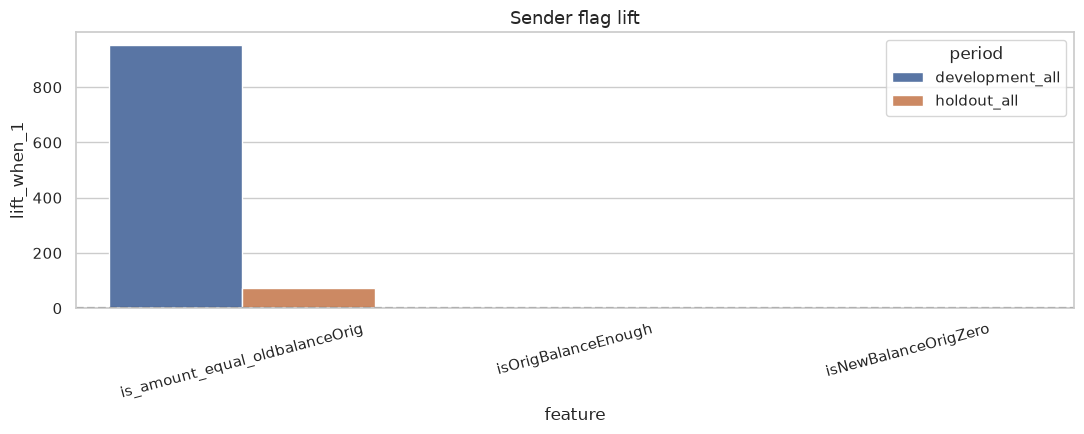

All types


,feature,isFraud,count,q25,median,q75,p95,p99
0,orig_balance_change_abs_error,0,6232481,"3,084.770000","69,284.720000","250,157.840000","702,316.910000","1,567,419.876000"
1,orig_balance_change_abs_error,1,6559,0.000000,0.000000,0.000000,0.000000,0.000000
2,amount_to_orig_ratio,0,6232481,0.234595,6.607561,"1,243,604,000.000000","31,361,853,999.999996","101,910,022,400.000000"
3,amount_to_orig_ratio,1,6559,1.000000,1.000000,1.000000,1.000000,1.000000
4,balance_drop_ratio,0,6232481,0.000000,0.000000,0.816835,1.000000,1.000000
5,balance_drop_ratio,1,6559,1.000000,1.000000,1.000000,1.000000,1.000000
6,orig_balance_after_expected,0,6232481,"-147,094.160000","-14,826.560000","49,620.880000","5,685,566.370000","16,006,058.988000"
7,orig_balance_after_expected,1,6559,0.000000,0.000000,0.000000,0.000000,"3,719,408.040400"
8,orig_balance_change,0,6232481,0.000000,0.000000,"10,092.000000","72,849.000000","210,041.242000"
9,orig_balance_change,1,6559,"126,403.390000","441,445.580000","1,500,939.980000","7,482,815.728000","10,000,000.000000"


TRANSFER/CASH_OUT only


,feature,isFraud,count,q25,median,q75,p95,p99
0,orig_balance_change_abs_error,0,2712564,"52,775.125000","144,424.435000","280,727.320000","911,783.430500","2,548,466.372700"
1,orig_balance_change_abs_error,1,6559,0.000000,0.000000,0.000000,0.000000,0.000000
2,amount_to_orig_ratio,0,2712564,5.147415,701.074992,"15,786,503,250.000000","54,305,072,800.000061","177,421,976,580.001007"
3,amount_to_orig_ratio,1,6559,1.000000,1.000000,1.000000,1.000000,1.000000
4,balance_drop_ratio,0,2712564,0.000000,0.206059,1.000000,1.000000,1.000000
5,balance_drop_ratio,1,6559,1.000000,1.000000,1.000000,1.000000,1.000000
6,orig_balance_after_expected,0,2712564,"-280,727.320000","-144,424.295000","-52,774.770000","75,726.409500","392,025.135600"
7,orig_balance_after_expected,1,6559,0.000000,0.000000,0.000000,0.000000,"3,719,408.040400"
8,orig_balance_change,0,2712564,0.000000,258.000000,"26,013.527500","139,676.930500","295,357.614000"
9,orig_balance_change,1,6559,"126,403.390000","441,445.580000","1,500,939.980000","7,482,815.728000","10,000,000.000000"


In [37]:
sender_binary = ["is_amount_equal_oldbalanceOrig", "isOrigBalanceEnough", "isNewBalanceOrigZero"]
sender_binary_evidence = pd.concat([
    binary_signal_table(df.loc[dev_mask, sender_binary + ["isFraud"]], sender_binary, "development_all"),
    binary_signal_table(df.loc[dev_mask & df["is_transfer_or_cashout"].eq(1), sender_binary + ["isFraud"]], sender_binary, "development_risky_types"),
    binary_signal_table(df.loc[holdout_mask, sender_binary + ["isFraud"]], sender_binary, "holdout_all"),
], ignore_index=True)
display(sender_binary_evidence)

plot_bin = sender_binary_evidence[sender_binary_evidence["period"].isin(["development_all","holdout_all"])]
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(data=plot_bin, x="feature", y="lift_when_1", hue="period", ax=ax)
ax.axhline(1, color="black", linestyle="--"); ax.set_title("Sender flag lift")
ax.tick_params(axis="x", rotation=15); plt.tight_layout(); plt.show()

sender_continuous = [
    "orig_balance_change_abs_error", "amount_to_orig_ratio", "balance_drop_ratio",
    "orig_balance_after_expected", "orig_balance_change",
]
print("All types"); display(robust_class_summary(df.loc[dev_mask, sender_continuous + ["isFraud"]], sender_continuous))
print("TRANSFER/CASH_OUT only")
display(robust_class_summary(df.loc[dev_mask & df["is_transfer_or_cashout"].eq(1), sender_continuous + ["isFraud"]], sender_continuous))

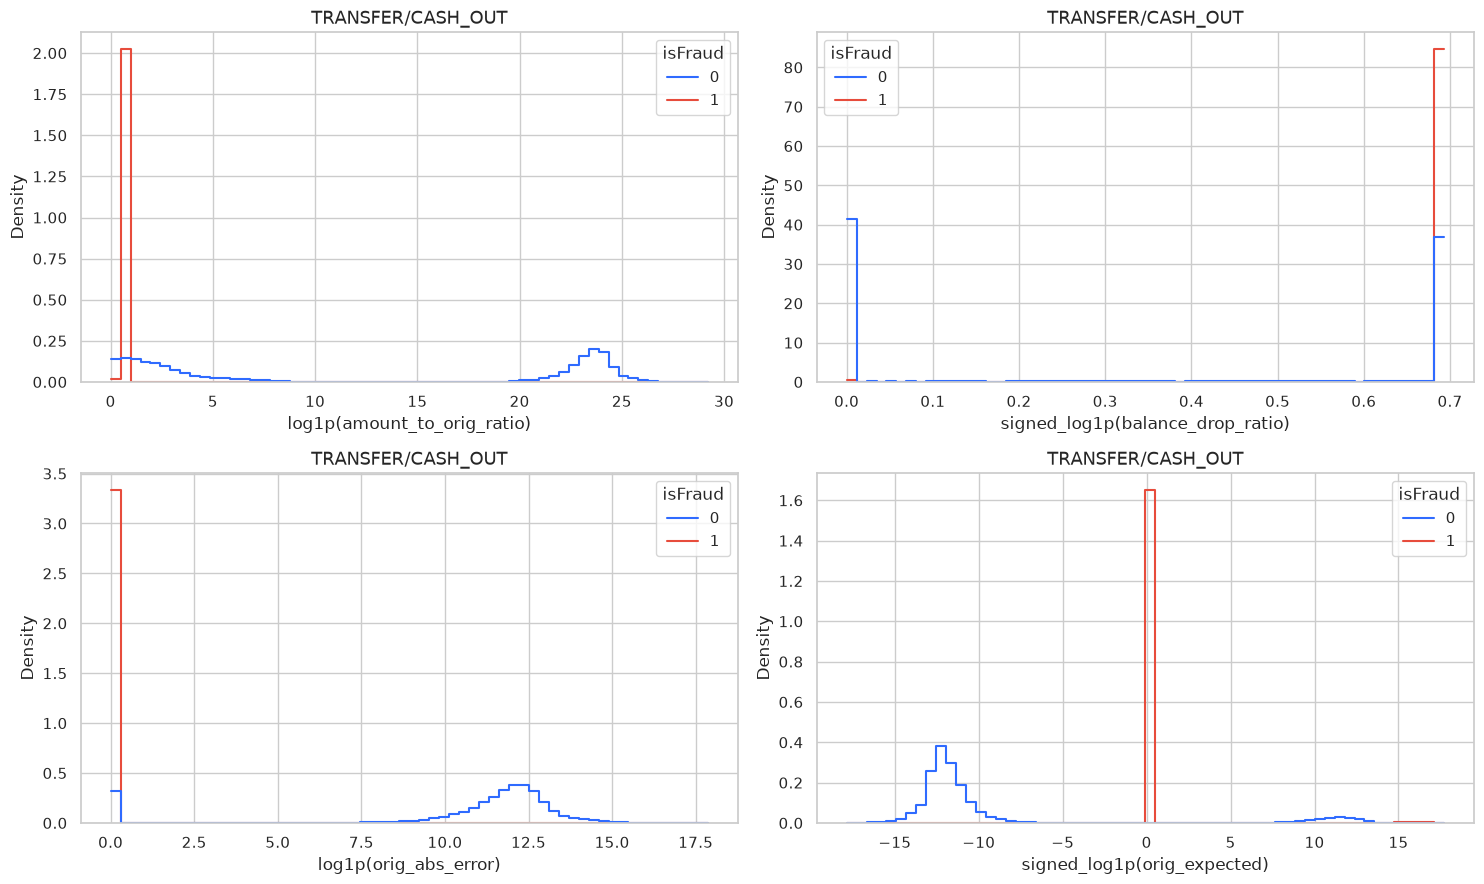

In [38]:
sender_plot = stratified_sample(df.loc[dev_mask & df["is_transfer_or_cashout"].eq(1), sender_continuous + ["isFraud"]]).copy()
sender_plot["_ratio"] = np.log1p(sender_plot["amount_to_orig_ratio"].clip(lower=0))
sender_plot["_drop"] = signed_log1p(sender_plot["balance_drop_ratio"])
sender_plot["_error"] = np.log1p(sender_plot["orig_balance_change_abs_error"].clip(lower=0))
sender_plot["_expected"] = signed_log1p(sender_plot["orig_balance_after_expected"])

specs = [("_ratio","log1p(amount_to_orig_ratio)"),("_drop","signed_log1p(balance_drop_ratio)"),
         ("_error","log1p(orig_abs_error)"),("_expected","signed_log1p(orig_expected)")]
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, (col, label) in zip(axes.flat, specs):
    sns.histplot(data=sender_plot, x=col, hue="isFraud", bins=60, stat="density",
        common_norm=False, element="step", fill=False, palette={0:BLUE,1:RED}, ax=ax)
    ax.set_xlabel(label); ax.set_title("TRANSFER/CASH_OUT")
plt.tight_layout(); plt.show()

## 11. Destination balance behavior

Phần này củng cố amount/destination ratio, signed error, actual change, expected balance và absolute error. Đọc lần lượt ở ba scope: toàn bộ; TRANSFER/CASH_OUT; rồi Customer trong TRANSFER/CASH_OUT. Nếu hiệu ứng chỉ mạnh ở Merchant hoặc mất sau phân tầng type, feature có thể đang học artifact simulator.


--- all ---


,feature,isFraud,count,q25,median,q75,p95,p99
0,amount_to_dest_ratio,0,6232481,0.160285,0.911532,"969,164,000.000000","13,740,996,999.999998","41,842,044,000.000031"
1,amount_to_dest_ratio,1,6559,4.236948,"11,512,530,000.000000","79,606,603,000.000000","545,636,956,499.999756","999,999,999,999.999878"
2,errorBalanceDest,0,6232481,0.000000,"3,497.350000","29,322.790000","455,643.100000","789,014.256000"
3,errorBalanceDest,1,6559,0.000000,"2,815.610000","446,521.390000","4,296,138.292000","10,000,000.000000"
4,dest_balance_change,0,6232481,0.000000,0.000000,"149,528.640000","560,734.090000","1,782,005.736000"
5,dest_balance_change,1,6559,0.000000,119.000000,"452,278.205000","4,253,125.017000","10,000,000.000000"
6,dest_balance_after_expected,0,6232481,"16,472.120000","313,907.010000","1,203,972.590000","5,567,071.260000","13,022,182.324000"
7,dest_balance_after_expected,1,6559,"206,775.105000","724,414.430000","2,230,432.560000","9,111,288.577000","11,692,090.615600"
8,dest_balance_change_abs_error,0,6232481,0.000000,"5,156.550000","43,667.860000","490,580.590000","878,751.264000"
9,dest_balance_change_abs_error,1,6559,0.000000,"12,477.960000","456,877.650000","4,343,741.666000","10,000,000.000000"



--- risky_types ---


,feature,isFraud,count,q25,median,q75,p95,p99
0,amount_to_dest_ratio,0,2712564,0.091077,0.318612,0.971026,"23,573,685,200.000011","63,966,386,570.000175"
1,amount_to_dest_ratio,1,6559,4.236948,"11,512,530,000.000000","79,606,603,000.000000","545,636,956,499.999756","999,999,999,999.999878"
2,errorBalanceDest,0,2712564,0.000000,0.000000,0.000000,0.010000,"241,384.503700"
3,errorBalanceDest,1,6559,0.000000,"2,815.610000","446,521.390000","4,296,138.292000","10,000,000.000000"
4,dest_balance_change,0,2712564,"81,952.947500","175,737.285000","323,822.697500","1,057,117.065000","2,820,856.693500"
5,dest_balance_change,1,6559,0.000000,119.000000,"452,278.205000","4,253,125.017000","10,000,000.000000"
6,dest_balance_after_expected,0,2712564,"328,987.720000","816,837.615000","2,094,770.202500","7,634,971.052500","16,530,806.279600"
7,dest_balance_after_expected,1,6559,"206,775.105000","724,414.430000","2,230,432.560000","9,111,288.577000","11,692,090.615600"
8,dest_balance_change_abs_error,0,2712564,0.000000,0.000000,0.010000,"182,766.918500","678,816.610300"
9,dest_balance_change_abs_error,1,6559,0.000000,"12,477.960000","456,877.650000","4,343,741.666000","10,000,000.000000"



--- risky_types_customer ---


,feature,isFraud,count,q25,median,q75,p95,p99
0,amount_to_dest_ratio,0,2712564,0.091077,0.318612,0.971026,"23,573,685,200.000011","63,966,386,570.000175"
1,amount_to_dest_ratio,1,6559,4.236948,"11,512,530,000.000000","79,606,603,000.000000","545,636,956,499.999756","999,999,999,999.999878"
2,errorBalanceDest,0,2712564,0.000000,0.000000,0.000000,0.010000,"241,384.503700"
3,errorBalanceDest,1,6559,0.000000,"2,815.610000","446,521.390000","4,296,138.292000","10,000,000.000000"
4,dest_balance_change,0,2712564,"81,952.947500","175,737.285000","323,822.697500","1,057,117.065000","2,820,856.693500"
5,dest_balance_change,1,6559,0.000000,119.000000,"452,278.205000","4,253,125.017000","10,000,000.000000"
6,dest_balance_after_expected,0,2712564,"328,987.720000","816,837.615000","2,094,770.202500","7,634,971.052500","16,530,806.279600"
7,dest_balance_after_expected,1,6559,"206,775.105000","724,414.430000","2,230,432.560000","9,111,288.577000","11,692,090.615600"
8,dest_balance_change_abs_error,0,2712564,0.000000,0.000000,0.010000,"182,766.918500","678,816.610300"
9,dest_balance_change_abs_error,1,6559,0.000000,"12,477.960000","456,877.650000","4,343,741.666000","10,000,000.000000"


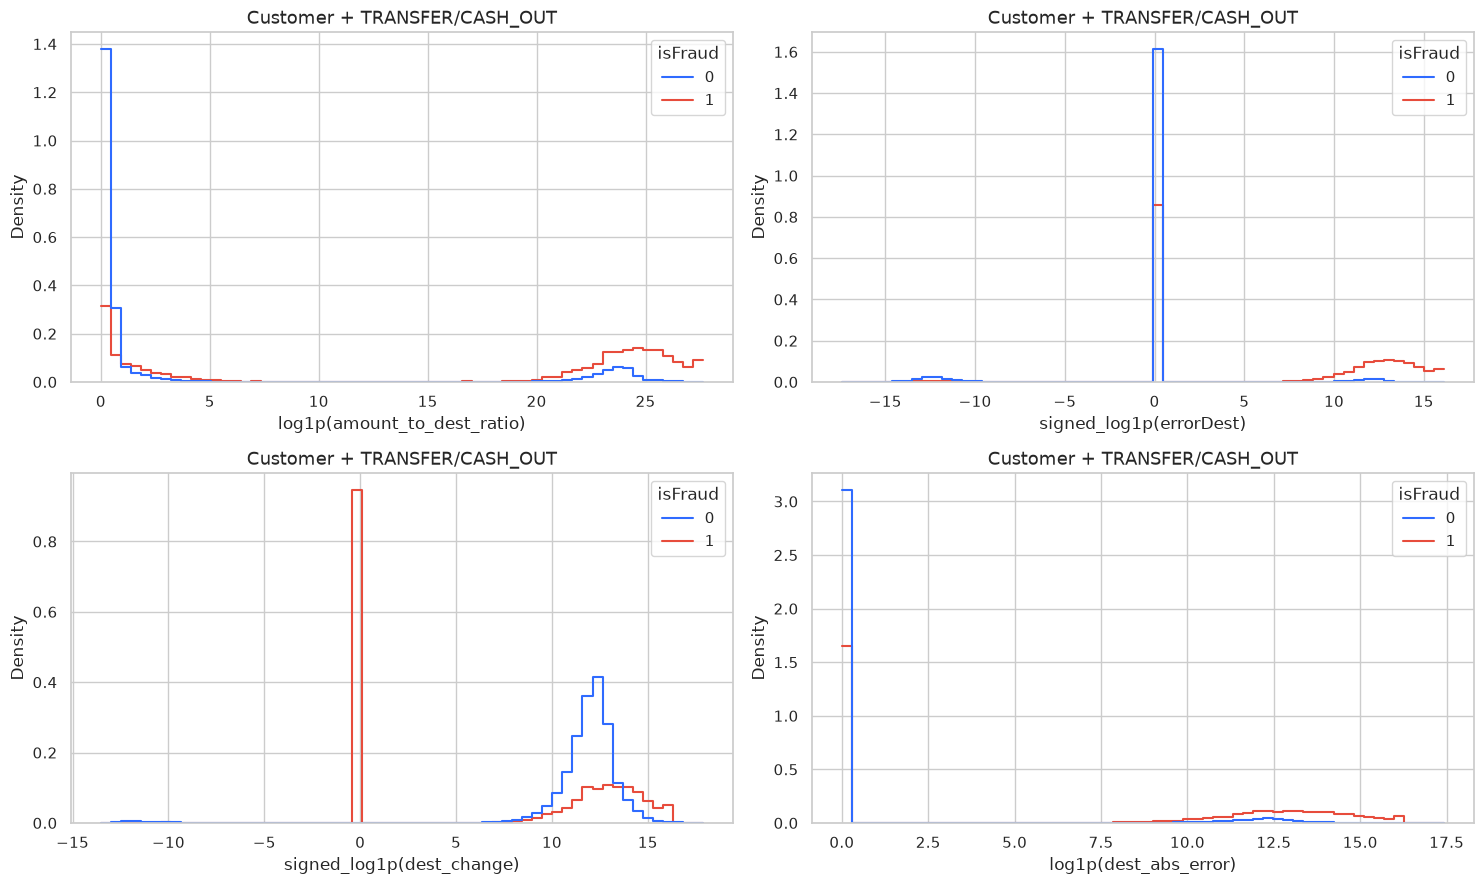

In [39]:
destination_continuous = [
    "amount_to_dest_ratio", "errorBalanceDest", "dest_balance_change",
    "dest_balance_after_expected", "dest_balance_change_abs_error",
]
scopes = {
    "all": dev_mask,
    "risky_types": dev_mask & df["is_transfer_or_cashout"].eq(1),
    "risky_types_customer": dev_mask & df["is_transfer_or_cashout"].eq(1) & df["dest_channel"].eq("Customer"),
}
for name, mask_ in scopes.items():
    print(f"\n--- {name} ---")
    display(robust_class_summary(df.loc[mask_, destination_continuous + ["isFraud"]], destination_continuous))

dest_plot = stratified_sample(df.loc[scopes["risky_types_customer"], destination_continuous + ["isFraud"]]).copy()
dest_plot["_ratio"] = np.log1p(dest_plot["amount_to_dest_ratio"].clip(lower=0))
dest_plot["_error"] = signed_log1p(dest_plot["errorBalanceDest"])
dest_plot["_change"] = signed_log1p(dest_plot["dest_balance_change"])
dest_plot["_abs_error"] = np.log1p(dest_plot["dest_balance_change_abs_error"].clip(lower=0))
specs = [("_ratio","log1p(amount_to_dest_ratio)"),("_error","signed_log1p(errorDest)"),
         ("_change","signed_log1p(dest_change)"),("_abs_error","log1p(dest_abs_error)")]
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, (col, label) in zip(axes.flat, specs):
    sns.histplot(data=dest_plot, x=col, hue="isFraud", bins=60, stat="density",
        common_norm=False, element="step", fill=False, palette={0:BLUE,1:RED}, ax=ax)
    ax.set_xlabel(label); ax.set_title("Customer + TRANSFER/CASH_OUT")
plt.tight_layout(); plt.show()

## 12. Destination history và amount_to_dest_cum_avg_ratio

Feature này hỏi: giao dịch hiện tại lớn gấp bao nhiêu lần trung bình những giao dịch destination đã nhận **trước đó**? ID thô được thay bằng tín hiệu hành vi.

Hạn chế: step chỉ có độ phân giải một giờ. Nếu cùng destination có nhiều dòng cùng step, thứ tự trong file không phải thứ tự thời gian thật; cumsum sẽ coi một số dòng cùng giờ là quá khứ. Production nên có timestamp chi tiết hoặc chỉ tổng hợp tới step−1.

,history_band,total,fraud_count,fraud_rate,fraud_capture,lift_vs_base,ci_low,ci_high
0,first,2666756,4121,0.001545,0.628297,1.469940,0.001499,0.001593
1,1_prior,450594,456,0.001012,0.069523,0.962630,0.000923,0.001109
2,2_5,1208322,934,0.000773,0.142400,0.735266,0.000725,0.000824
3,6_20,1554491,876,0.000564,0.133557,0.536039,0.000527,0.000602
4,over_20,358877,172,0.000479,0.026224,0.455893,0.000413,0.000556


,period,state,rows,fraud_rate,ratio_median,ratio_p95,ratio_p99
0,development,first_destination_tx,2666756,0.001545,"1,268,738,500.000000","27,771,219,499.999996","65,966,437,450.000282"
1,development,has_prior_history,3572284,0.000682,0.787154,4.751148,16.638582
2,holdout,first_destination_tx,55606,0.018937,"1,147,828,000.000000","28,929,601,249.999996","101,324,512,649.999985"
3,holdout,has_prior_history,67974,0.008842,0.766448,4.468239,17.635123


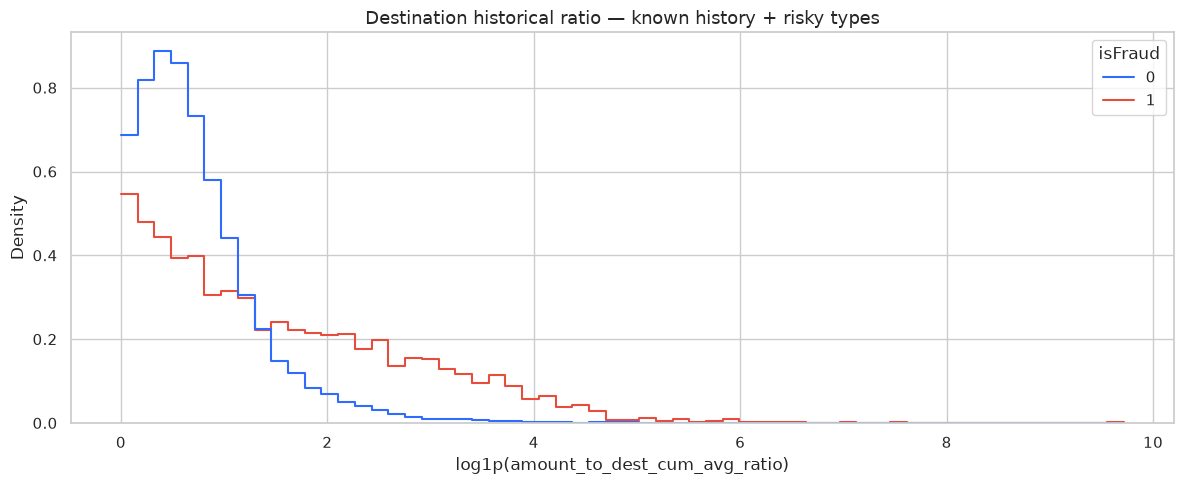

In [40]:
dest_group = df.groupby("nameDest", sort=False, observed=True)
df["dest_cum_count"] = dest_group.cumcount().astype("int32")
df["dest_cum_sum"] = dest_group["amount"].cumsum() - df["amount"]
df["dest_cum_avg"] = df["dest_cum_sum"]/(df["dest_cum_count"] + EPSILON)
df["amount_to_dest_cum_avg_ratio"] = df["amount"]/(df["dest_cum_avg"] + EPSILON)

history_band = pd.cut(df.loc[dev_mask, "dest_cum_count"],
    [-1,0,1,5,20,np.inf], labels=["first","1_prior","2_5","6_20","over_20"])
history_frame = pd.DataFrame({"history_band": history_band,
                              "isFraud": df.loc[dev_mask,"isFraud"].to_numpy()})
display(fraud_profile(history_frame, "history_band"))

rows = []
for period_name, period_mask in [("development",dev_mask),("holdout",holdout_mask)]:
    for state, state_mask in [("first_destination_tx",df["dest_cum_count"].eq(0)),
                              ("has_prior_history",df["dest_cum_count"].gt(0))]:
        x = df.loc[period_mask & state_mask, ["amount_to_dest_cum_avg_ratio","isFraud"]]
        rows.append({"period":period_name,"state":state,"rows":len(x),
                     "fraud_rate":x["isFraud"].mean(),
                     "ratio_median":x["amount_to_dest_cum_avg_ratio"].median(),
                     "ratio_p95":x["amount_to_dest_cum_avg_ratio"].quantile(.95),
                     "ratio_p99":x["amount_to_dest_cum_avg_ratio"].quantile(.99)})
display(pd.DataFrame(rows))

history_plot = stratified_sample(df.loc[
    dev_mask & df["dest_cum_count"].gt(0) & df["is_transfer_or_cashout"].eq(1),
    ["amount_to_dest_cum_avg_ratio", "isFraud"],
]).copy()
history_plot["_log_ratio"] = np.log1p(history_plot["amount_to_dest_cum_avg_ratio"].clip(lower=0))
sns.histplot(data=history_plot, x="_log_ratio", hue="isFraud", bins=60, stat="density",
    common_norm=False, element="step", fill=False, palette={0:BLUE,1:RED})
plt.title("Destination historical ratio — known history + risky types")
plt.xlabel("log1p(amount_to_dest_cum_avg_ratio)"); plt.tight_layout(); plt.show()

## 13. Scorecard đúng 20 selected features

Availability:
- **Pre-transaction:** tính trước khi thực hiện.
- **Past-only:** cần state lịch sử, không cần kết quả hiện tại.
- **Post-transaction:** cần newbalance; chỉ hợp lệ cho phát hiện sau ghi sổ.

Bảng cũng ghi RF probe importance lấy từ bước selection hiện có. Importance là bằng chứng model-based, không phải bằng chứng nhân quả.

In [41]:
SELECTED_FEATURES = [
    "is_amount_equal_oldbalanceOrig","orig_balance_change_abs_error","isOrigBalanceEnough",
    "amount_to_orig_ratio","balance_drop_ratio","isNewBalanceOrigZero",
    "orig_balance_after_expected","orig_balance_change","is_transfer_or_cashout",
    "amount_to_dest_cum_avg_ratio","amount_to_dest_ratio","type_PAYMENT",
    "errorBalanceDest","type_TRANSFER","type_CASH_OUT","is_large_amount","hour_of_day",
    "dest_balance_change","dest_balance_after_expected","dest_balance_change_abs_error",
]
assert len(SELECTED_FEATURES) == 20 and set(SELECTED_FEATURES).issubset(df.columns)

importance_values = [
    .245788,.156128,.076348,.066282,.058530,.057248,.050281,.047872,.043066,.017646,
    .014747,.010612,.005485,.004822,.002826,.002473,.002391,.002263,.002043,.001111,
]
availability = [
    "Pre","Post","Pre","Pre","Post","Post","Pre","Post","Pre","Past-only",
    "Pre","Pre","Post","Pre","Pre","Pre","Pre","Post","Pre","Post",
]
hypotheses = [
    "Rút/chuyển toàn bộ số dư sender","Độ lệch tuyệt đối số dư sender","Sender có đủ tiền",
    "Amount tương đối với sender balance","Tỷ lệ sender bị giảm số dư","Sender bị làm trống",
    "Sender balance dự kiến","Mức giảm sender balance thực tế","Nhóm type chứa fraud",
    "Bất thường so với lịch sử destination","Amount tương đối với destination balance",
    "Context/tín hiệu âm PAYMENT","Sai lệch có dấu destination","Cờ TRANSFER","Cờ CASH_OUT",
    "Amount lớn theo train IQR","Chu kỳ giao dịch theo giờ","Mức tăng destination thực tế",
    "Destination balance dự kiến","Độ lệch tuyệt đối destination",
]
risks = [
    "Exact equality","Scoring-time leakage","Tất định từ expected balance","Epsilon/zero balance",
    "Leakage + epsilon","Scoring-time leakage","Type-dependent","Scoring-time leakage",
    "Redundant với 2 one-hot","Same-step + epsilon","Merchant + epsilon","Simulator association",
    "Leakage + merchant","Redundancy","Redundancy","Train-fit threshold","Cyclical encoding",
    "Leakage + merchant","Type/merchant-dependent","Leakage + deterministic redundancy",
]
catalog = pd.DataFrame({
    "feature":SELECTED_FEATURES,"business_hypothesis":hypotheses,
    "availability":availability,"main_risk":risks,"rf_probe_importance":importance_values,
})
display(catalog)

,feature,business_hypothesis,availability,main_risk,rf_probe_importance
0,is_amount_equal_oldbalanceOrig,Rút/chuyển toàn bộ số dư sender,Pre,Exact equality,0.245788
1,orig_balance_change_abs_error,Độ lệch tuyệt đối số dư sender,Post,Scoring-time leakage,0.156128
2,isOrigBalanceEnough,Sender có đủ tiền,Pre,Tất định từ expected balance,0.076348
3,amount_to_orig_ratio,Amount tương đối với sender balance,Pre,Epsilon/zero balance,0.066282
4,balance_drop_ratio,Tỷ lệ sender bị giảm số dư,Post,Leakage + epsilon,0.058530
5,isNewBalanceOrigZero,Sender bị làm trống,Post,Scoring-time leakage,0.057248
6,orig_balance_after_expected,Sender balance dự kiến,Pre,Type-dependent,0.050281
7,orig_balance_change,Mức giảm sender balance thực tế,Post,Scoring-time leakage,0.047872
8,is_transfer_or_cashout,Nhóm type chứa fraud,Pre,Redundant với 2 one-hot,0.043066
9,amount_to_dest_cum_avg_ratio,Bất thường so với lịch sử destination,Past-only,Same-step + epsilon,0.017646


### 13.1. Effect size và holdout stability

Binary feature dùng lift/capture trên toàn bộ partition. Continuous feature dùng univariate AUC trên mẫu phân tầng; không dùng Average Precision vì prevalence đã thay đổi do sampling. AUC gần 0.5 không tự động là lý do bỏ — quan hệ có thể phi tuyến hoặc chỉ xuất hiện trong interaction.

,period,feature,support_when_1,fraud_rate_when_1,fraud_rate_when_0,risk_ratio_1_vs_0,lift_when_1,fraud_capture_when_1,ci_low_when_1,ci_high_when_1
0,development,is_amount_equal_oldbalanceOrig,0.001031,1.000000,0.000021,"48,314.806202",951.218174,0.980332,0.999403,1.000000
1,development,isOrigBalanceEnough,0.358127,0.002923,0.000007,403.577389,2.779958,0.995579,0.002853,0.002994
2,development,isNewBalanceOrigZero,0.568022,0.001821,0.000039,46.296998,1.732045,0.983839,0.001777,0.001866
3,development,is_transfer_or_cashout,0.435824,0.002412,0.000000,inf,2.294505,1.000000,0.002355,0.002471
4,development,type_PAYMENT,0.337964,0.000000,0.001588,0.000000,0.000000,0.000000,-0.000000,0.000002
5,development,type_TRANSFER,0.083487,0.006278,0.000575,10.914466,5.971593,0.498552,0.006067,0.006496
6,development,type_CASH_OUT,0.352337,0.001496,0.000809,1.848875,1.423208,0.501448,0.001446,0.001548
7,development,is_large_amount,0.053136,0.009324,0.000587,15.882373,8.868893,0.471261,0.009002,0.009657
8,holdout,is_amount_equal_oldbalanceOrig,0.012979,1.000000,0.000410,"2,439.520000",74.715840,0.969770,0.997611,1.000000
9,holdout,isOrigBalanceEnough,0.397880,0.033638,0.000000,inf,2.513321,1.000000,0.032081,0.035269


,period,feature,auc_raw_direction,auc_direction_free,median_non_fraud,median_fraud
0,development,orig_balance_change_abs_error,0.078493,0.921507,"68,954.725000",0.000000
1,development,amount_to_orig_ratio,0.358852,0.641148,6.570108,1.000000
2,development,balance_drop_ratio,0.973924,0.973924,0.000000,1.000000
3,development,orig_balance_after_expected,0.644917,0.644917,"-14,817.800000",0.000000
4,development,orig_balance_change,0.964836,0.964836,0.000000,"441,445.580000"
5,development,amount_to_dest_cum_avg_ratio,0.753386,0.753386,2.497576,"10,200,936,999.999998"
6,development,amount_to_dest_ratio,0.765727,0.765727,0.917390,"11,512,530,000.000000"
7,development,errorBalanceDest,0.568295,0.568295,"3,439.510000","2,815.610000"
8,development,hour_of_day,0.336126,0.663874,16.000000,11.000000
9,development,dest_balance_change,0.617083,0.617083,0.000000,119.000000


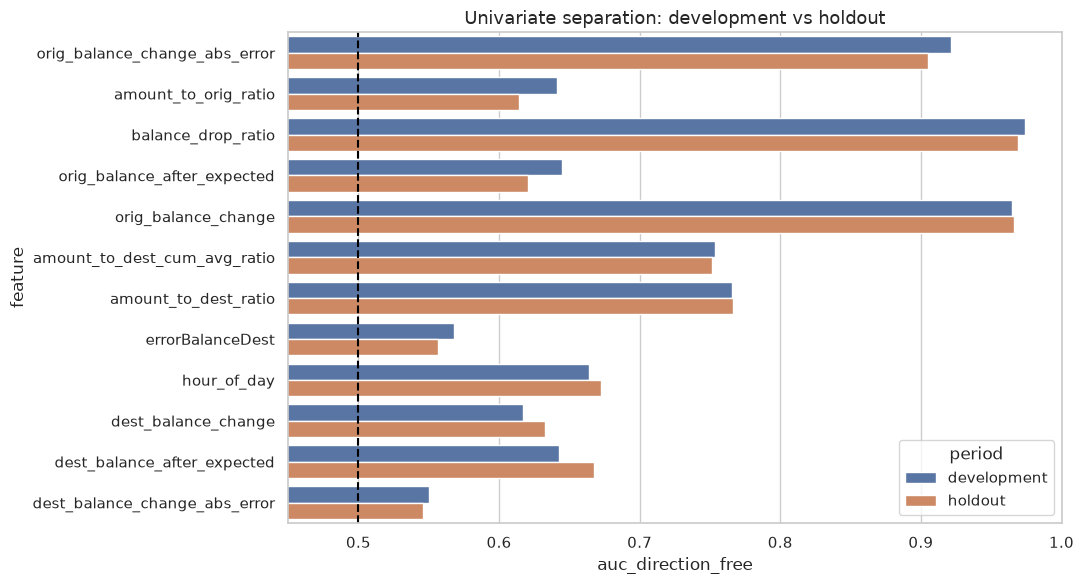

In [42]:
binary_features = [
    "is_amount_equal_oldbalanceOrig","isOrigBalanceEnough","isNewBalanceOrigZero",
    "is_transfer_or_cashout","type_PAYMENT","type_TRANSFER","type_CASH_OUT","is_large_amount",
]
continuous_features = [x for x in SELECTED_FEATURES if x not in binary_features]
binary_scorecard = pd.concat([
    binary_signal_table(df.loc[dev_mask, binary_features + ["isFraud"]], binary_features, "development"),
    binary_signal_table(df.loc[holdout_mask, binary_features + ["isFraud"]], binary_features, "holdout"),
], ignore_index=True)
continuous_scorecard = pd.concat([
    univariate_auc_table(df.loc[dev_mask, continuous_features + ["isFraud"]], continuous_features, "development"),
    univariate_auc_table(df.loc[holdout_mask, continuous_features + ["isFraud"]], continuous_features, "holdout"),
], ignore_index=True)
display(binary_scorecard)
display(continuous_scorecard)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=continuous_scorecard, y="feature", x="auc_direction_free", hue="period", ax=ax)
ax.axvline(.5, color="black", linestyle="--"); ax.set_xlim(.45,1)
ax.set_title("Univariate separation: development vs holdout")
plt.tight_layout(); plt.show()

## 14. Correlation và deterministic redundancy

Correlation không bắt hết quan hệ OR, abs hoặc threshold. Audit dưới kiểm tra trực tiếp các identity:

- risk flag = TRANSFER OR CASH_OUT
- destination absolute error = abs(signed error)
- destination error = amount − destination change
- enough flag = expected origin balance ≥ 0
- origin absolute error = abs(origin change − amount)

Feature redundant đôi khi giúp cây split dễ hơn, nhưng làm importance thiếu ổn định. Cần ablation/permutation importance, không chỉ Pearson pruning.

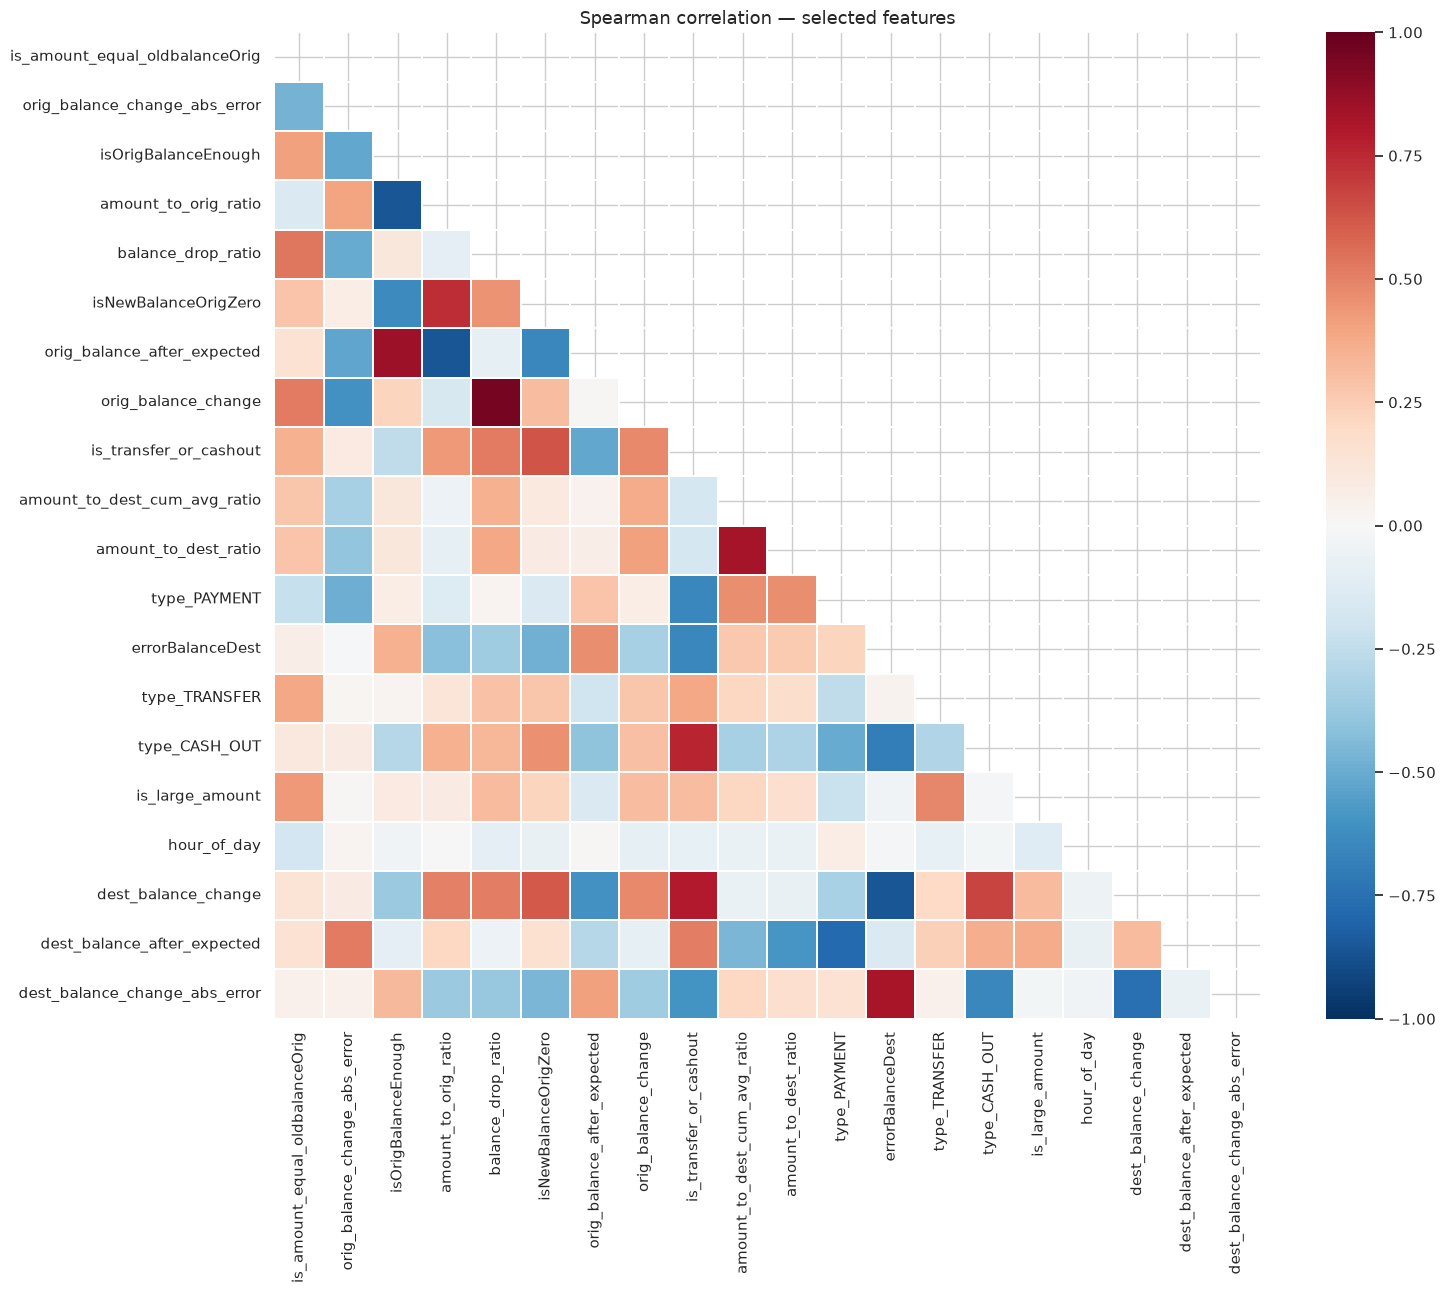

,feature_1,feature_2,spearman
3,balance_drop_ratio,orig_balance_change,0.955957
2,amount_to_orig_ratio,orig_balance_after_expected,-0.859000
1,isOrigBalanceEnough,orig_balance_after_expected,0.858838
0,isOrigBalanceEnough,amount_to_orig_ratio,-0.858207
4,errorBalanceDest,dest_balance_change,-0.855992


,identity_holds
risk_flag == transfer OR cashout,True
dest_abs_error == abs(errorDest),True
errorDest == amount - dest_change,False
enough == expected_origin >= 0,True
orig_abs_error == abs(orig_change-amount),True


In [43]:
corr_sample = stratified_sample(df.loc[dev_mask, SELECTED_FEATURES + ["isFraud"]], 50_000)[SELECTED_FEATURES]
corr_sample = corr_sample.replace([np.inf,-np.inf],np.nan)
corr_sample = corr_sample.fillna(corr_sample.median(numeric_only=True))
corr = corr_sample.corr(method="spearman")
plt.figure(figsize=(16,13))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr,dtype=bool)), cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=.25)
plt.title("Spearman correlation — selected features"); plt.tight_layout(); plt.show()

strong = []
for i, a in enumerate(corr.columns):
    for b in corr.columns[i+1:]:
        if abs(corr.loc[a,b]) >= .85:
            strong.append({"feature_1":a,"feature_2":b,"spearman":corr.loc[a,b]})
display(pd.DataFrame(strong).sort_values("spearman", key=abs, ascending=False)
        if strong else pd.DataFrame(columns=["feature_1","feature_2","spearman"]))

identity_audit = pd.Series({
    "risk_flag == transfer OR cashout": np.array_equal(
        df["is_transfer_or_cashout"], (df["type_TRANSFER"].astype(bool)|df["type_CASH_OUT"].astype(bool)).astype("int8")),
    "dest_abs_error == abs(errorDest)": np.allclose(df["dest_balance_change_abs_error"],df["errorBalanceDest"].abs()),
    "errorDest == amount - dest_change": np.allclose(df["errorBalanceDest"],df["amount"]-df["dest_balance_change"]),
    "enough == expected_origin >= 0": np.array_equal(df["isOrigBalanceEnough"],df["orig_balance_after_expected"].ge(0).astype("int8")),
    "orig_abs_error == abs(orig_change-amount)": np.allclose(df["orig_balance_change_abs_error"],(df["orig_balance_change"]-df["amount"]).abs()),
}, name="identity_holds")
display(identity_audit.to_frame())

## 15. Vì sao bỏ trường gốc và feature ứng viên khác?

Feature selection hiện tại trong <code>4_feature_investigation.ipynb</code>:

1. RF probe xếp hạng 43 candidates.
2. Với cặp |Pearson correlation| > 0.9, bỏ feature importance thấp hơn.
3. Chọn top 20 sau pruning; chúng chiếm khoảng 99.53% impurity importance.

Đây không phải kết luận thuần EDA. RF impurity importance bị ảnh hưởng bởi correlated features; cutoff 20 cũng chịu ràng buộc mục tiêu 15–25 feature.

In [44]:
raw_decisions = pd.DataFrame([
    ["step","Không làm input trực tiếp","Ordering/split; hour_of_day giữ chu kỳ"],
    ["type","Mã hóa","Thay chuỗi bằng one-hot và risk flag"],
    ["amount","Không trong model cuối","Ratio/large/expected biểu diễn lại; vẫn giữ cho cost metric"],
    ["nameOrig","Không trực tiếp","Cardinality/memorization; chỉ dùng past history"],
    ["oldbalanceOrg","Biến đổi","Enough, expected, ratio, change, error"],
    ["newbalanceOrig","Biến đổi/Post-only","Drop, zero, change, error"],
    ["nameDest","Không trực tiếp","Cardinality; dùng destination history/merchant audit"],
    ["oldbalanceDest","Biến đổi","Ratio, expected, change, error"],
    ["newbalanceDest","Biến đổi/Post-only","Change và error"],
    ["isFraud","Target","Không bao giờ đưa vào X"],
], columns=["raw_field","decision","reason"])
display(raw_decisions)

correlation_pruned = [
    "amount","amount_to_dest_avg_ratio","amount_to_orig_avg_ratio","dest_cum_count",
    "errorBalanceOrig","isNewBalanceDestZero","is_full_balance_transfer",
    "is_merchant_dest","orig_cum_avg",
]
below_elbow = [
    "isDestBalanceZero","type_CASH_IN","dest_cum_sum","dest_amount_last_24h",
    "dest_cum_avg","day_of_month","isOrigBalanceZero","dest_unique_orig_count",
    "dest_txn_last_24h","day_of_week","is_first_dest_tx","type_DEBIT",
    "orig_cum_count","orig_cum_sum",
]
display(pd.concat([
    pd.DataFrame({"feature":correlation_pruned,"reason":"Correlation-pruned |corr| > 0.9"}),
    pd.DataFrame({"feature":below_elbow,"reason":"Below RF-importance cutoff"}),
], ignore_index=True))

,raw_field,decision,reason
0,step,Không làm input trực tiếp,Ordering/split; hour_of_day giữ chu kỳ
1,type,Mã hóa,Thay chuỗi bằng one-hot và risk flag
2,amount,Không trong model cuối,Ratio/large/expected biểu diễn lại; vẫn giữ cho cost metric
3,nameOrig,Không trực tiếp,Cardinality/memorization; chỉ dùng past history
4,oldbalanceOrg,Biến đổi,"Enough, expected, ratio, change, error"
5,newbalanceOrig,Biến đổi/Post-only,"Drop, zero, change, error"
6,nameDest,Không trực tiếp,Cardinality; dùng destination history/merchant audit
7,oldbalanceDest,Biến đổi,"Ratio, expected, change, error"
8,newbalanceDest,Biến đổi/Post-only,Change và error
9,isFraud,Target,Không bao giờ đưa vào X


,feature,reason
0,amount,Correlation-pruned |corr| > 0.9
1,amount_to_dest_avg_ratio,Correlation-pruned |corr| > 0.9
2,amount_to_orig_avg_ratio,Correlation-pruned |corr| > 0.9
3,dest_cum_count,Correlation-pruned |corr| > 0.9
4,errorBalanceOrig,Correlation-pruned |corr| > 0.9
5,isNewBalanceDestZero,Correlation-pruned |corr| > 0.9
6,is_full_balance_transfer,Correlation-pruned |corr| > 0.9
7,is_merchant_dest,Correlation-pruned |corr| > 0.9
8,orig_cum_avg,Correlation-pruned |corr| > 0.9
9,isDestBalanceZero,Below RF-importance cutoff


## 16. Leakage/serving audit và kết luận

### Nếu mục tiêu là chặn trước giao dịch

Bảy feature sau không khả dụng vì cần <code>newbalance*</code>:

- orig_balance_change_abs_error
- balance_drop_ratio
- isNewBalanceOrigZero
- orig_balance_change
- errorBalanceDest
- dest_balance_change
- dest_balance_change_abs_error

Chúng chỉ hợp lệ cho detection sau khi ghi sổ.

### Tiêu chí giữ feature sau khi chạy notebook

1. Giả thuyết nghiệp vụ rõ.
2. Lift/capture/AUC có ý nghĩa trên development.
3. Hiệu ứng ổn định trên holdout.
4. Còn tín hiệu sau phân tầng type và Customer/Merchant.
5. Khả dụng đúng thời điểm scoring.
6. Không chỉ là artifact/duplicate, hoặc việc giữ đã được ablation chứng minh.

### Nguồn gốc 20 feature

- Type EDA → TRANSFER, CASH_OUT, PAYMENT và risk flag.
- Amount EDA → large flag và relative ratios.
- Sender balance EDA → đủ tiền, rút sạch, expected/actual change và discrepancy.
- Destination EDA → ratio, expected/actual change và discrepancy, có merchant audit.
- Entity/history EDA → past-average ratio thay raw destination ID.
- Time EDA → hour_of_day; step chỉ ordering/split.
- RF probe + correlation pruning → danh sách cuối.

### Bước tiếp theo

Chốt pre/post-transaction use case; train time-based baseline; ablation/permutation importance theo nhóm; đánh giá AUC-PR, recall, confusion matrix và cost threshold; chỉ mở final test sau khi khóa pipeline. Notebook không ghi feature file và không sửa dữ liệu nguồn.

In [45]:
availability_summary = catalog.groupby("availability").agg(
    feature_count=("feature","size"),
    features=("feature",lambda x:", ".join(x)),
)
display(availability_summary)
print("Pre/Past-only:", catalog["availability"].isin(["Pre","Past-only"]).sum())
print("Post-transaction:", catalog["availability"].eq("Post").sum())

,feature_count,features
availability,,
Past-only,1,amount_to_dest_cum_avg_ratio
Post,7,"orig_balance_change_abs_error, balance_drop_ratio, isNewBalanceOrigZero, orig_balance_change, errorBalanceDest, dest..."
Pre,12,"is_amount_equal_oldbalanceOrig, isOrigBalanceEnough, amount_to_orig_ratio, orig_balance_after_expected, is_transfer_..."


Pre/Past-only: 13
Post-transaction: 7
